In [ ]:
%pip install scipy numpy matplotlib

In [ ]:
import scipy.io
import numpy as np

# Substitua pelo nome correto do arquivo que você encontrar
caminho_arquivo = '../data/ACT_100_1/act_100_1.mat' 

try:
    # O loadmat carrega o arquivo .mat como um dicionário Python
    dados_mat = scipy.io.loadmat(caminho_arquivo)
    
    # Mostra todas as chaves dentro do arquivo (ignora as chaves padrão do MATLAB)
    chaves_relevantes = [k for k in dados_mat.keys() if not k.startswith('__')]
    print(f"Variáveis encontradas no arquivo: {chaves_relevantes}")
    
    # Supondo que a matriz principal se chame 'csi_data' (mude conforme sua saída acima)
    chave_matriz = chaves_relevantes[0] 
    matriz_csi = dados_mat[chave_matriz]
    
    print(f"Dimensões da Matriz CSI: {matriz_csi.shape}")
    print(f"Tipo do dado: {matriz_csi.dtype}")
    
except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}")

Variáveis encontradas: ['trace']
O arquivo que você baixou foi gerado originalmente no software MATLAB. Quem gravou os dados salvou a variável principal com o nome trace (que significa "rastro" ou "coleta" em inglês).

Dimensões da Matriz CSI: (2901, 1)
O seu arquivo contém 2901 linhas e 1 coluna. Na prática, isso significa que o roteador capturou 2901 pacotes de Wi-Fi ao longo de alguns segundos. É como se fossem 2901 "fotos" do sinal.

Tipo do dado: object (O Grande Desafio)
Se você tivesse carregado uma imagem ou um áudio, o tipo seria um número decimal (float ou int). Mas o tipo retornou object.
Isso ocorre porque cada uma dessas 2901 linhas não é um simples número, mas sim uma Estrutura de Dados (Struct). É como se cada linha fosse uma pasta de computador. Dentro da linha 0, existem arquivos ocultos como: o horário em que o pacote chegou (timestamp), a força do sinal (rssi), os endereços MAC e, escondida lá dentro, a verdadeira matriz de números complexos do CSI.

Desempacotamento concluído! Pacotes válidos: 2901


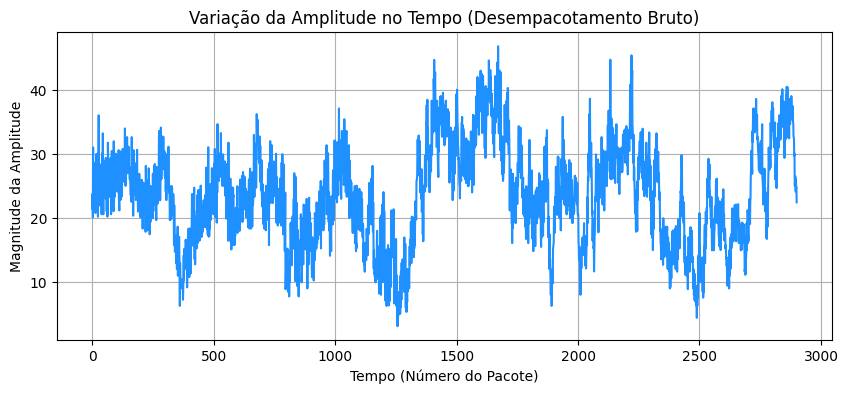

In [8]:
import numpy as np
import matplotlib.pyplot as plt

historico_amplitude = []
pacotes_lidos_com_sucesso = 0

# 1. Loop por todos os 2901 pacotes
for i in range(matriz_csi.shape[0]):
    try:
        pacote_atual = matriz_csi[i][0]
        matriz_escondida = pacote_atual['csi']
        
        # Converte para array
        arr = np.array(matriz_escondida)
        
        # 2. Desempacota as Caixas (Objects) até achar a matriz tridimensional pura
        while arr.dtype == object:
            arr = arr.flat[0] 
            
        # Neste ponto, o embrulho foi retirado. Aqui arr já é a matriz bruta (3, 3, 30)
        
        # 3. Calcula a Amplitude
        arr_amplitude = np.abs(arr)
        
        # 4. Pega o primeiríssimo número livre, independentemente do formato
        primeiro_valor_bruto = arr_amplitude.flat[0]
        
        historico_amplitude.append(primeiro_valor_bruto)
        pacotes_lidos_com_sucesso += 1
        
    except Exception as e:
        # Se algum pacote vier quebrado no arquivo, apenas pula ele
        continue

print(f"Desempacotamento concluído! Pacotes válidos: {pacotes_lidos_com_sucesso}")

# 5. Gerar o Gráfico
if pacotes_lidos_com_sucesso > 0:
    plt.figure(figsize=(10, 4))
    plt.plot(historico_amplitude, color='dodgerblue')
    plt.title("Variação da Amplitude no Tempo (Desempacotamento Bruto)")
    plt.xlabel("Tempo (Número do Pacote)")
    plt.ylabel("Magnitude da Amplitude")
    plt.grid(True)
    plt.show()
else:
    print("Nenhum pacote pôde ser convertido.")

Varredura dos Pacotes (Loop temporal): Lemos os 2901 pacotes de forma sequencial (representando o avanço do tempo).
Desempacotamento Automático (Unnesting): Criamos a rotina while arr.dtype == object. Essa rotina entra camada por camada do pacote até encontrar números matemáticos puros (removendo os "embrulhos" que o MATLAB deixou). Ao final desse processo, nós liberamos a matriz real do hardware, que geralmente tem um formato tridimensional (ex: 3 Antenas Transmissoras x 3 Antenas Receptoras x 30 Frequências).
Extração da Amplitude: Os equipamentos de Wi-Fi Sensing registram o sinal em números complexos (fase e amplitude combinadas). Aplicamos a função matemática de valor absoluto (np.abs) para extrair apenas a Amplitude (a magnitude do sinal naquele instante).
Isolamento da Frequência: Como o roteador captura mais de 270 sinais simultâneos em cada milissegundo (a matriz 3x3x30 citada no passo 2), o gerador de gráfico entrou em pane tentando desenhar matrizes em 3D. Resolvemos isso aplicando o comando .flat[0], que pinça apenas o sinal da primeiríssima combinação (Antena 1, Receptora 1, Frequência 1) para podermos analisar.
Plotagem do Gráfico: Com o dado limpo e isolado, plotamos o eixo Y (força da amplitude) contra o eixo X (pacotes avançando no tempo).
Conclusão para o Projeto: Estas pequenas ondinhas criadas no gráfico (as flutuações de amplitude no tempo) são as "sombras" geradas pela movimentação humana no ambiente. É exatamente essa variação que nosso futuro algoritmo de Machine Learning usará para agrupar as diferentes atividades.